<a href="https://colab.research.google.com/github/Dave-shift/CphA_Bradford_Assay/blob/main/bradford_standard_curve_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bradford Analysis

This notebook helps you plot a standards curve for a Bradford Assay.

* Step 1: Duplicate this Colab!
* Step 2: Drag and drop your excel file
* Step 3: Update the filename/path to your excel file as well as the position in the sheet of the content of "A1" on your plate. Note this isn't neccessarily in the top left cell of your excel, but that would be easiest.
* Step 4: Run the next few cells
* Step 5: Look at the plate "preview" and make sure it looks right
* Step 6: Update your standard concentrations (if neccessary)
* Step 7: Update the list of unknowns.
* Step 8: Run the rest of the cells.

Done!

In [ ]:
EXCEL_FILE_PATH = "/content/Book1.xlsx"
EXCEL_PLATE_ORIGIN = "C39"

In [ ]:
!git clone https://github.com/rmcl/bradford-analysis.git /content/bradford-analysis

import sys
sys.path.append('/content/bradford-analysis')


fatal: destination path '/content/bradford-analysis' already exists and is not an empty directory.


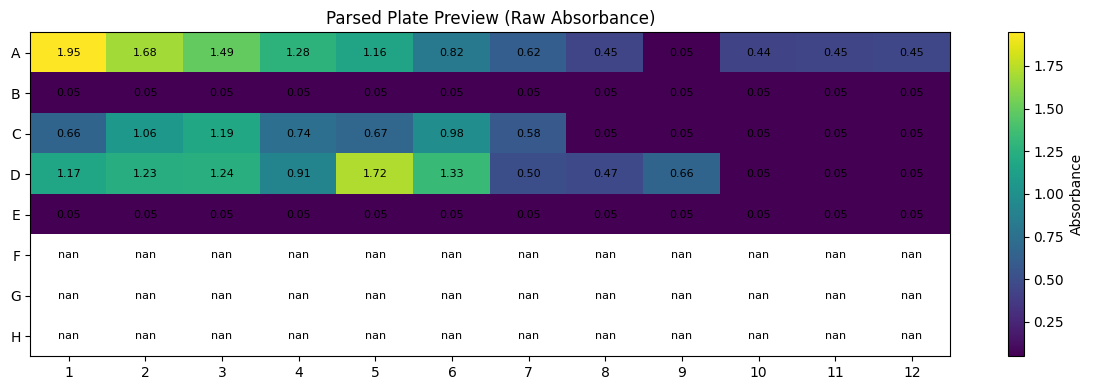

In [ ]:
# Make sure we are looking at the right Excel file

from bradford_analysis.plate import PlateReader

plate = PlateReader.from_excel(
    EXCEL_FILE_PATH,
    origin=EXCEL_PLATE_ORIGIN   # top-left well of A1 in the spreadsheet (not the label, but the content of well A1!)
)

plate.preview()

In [ ]:
from bradford_analysis.analysis import BradfordAnalysis

analysis = BradfordAnalysis(plate)

# standards (well → concentration in µg/mL)
concs = [2000, 1500, 1000, 750, 500, 250, 125, 25]
for i, c in enumerate(concs, start=1):
    analysis.define_standard(f"A{i}", c)

analysis.define_blank("A10")
analysis.define_blank("A11")
analysis.define_blank("A12")


# This example is needlessly complicated. Remove all of these and just keep
analysis.define_sample("RM2-A", "C1", 10)
analysis.define_sample("RM1-B", "D1", 50)
analysis.define_sample("RM2-B", "D2", 50)


analysis.fit()

results = analysis.sample_results()

for name, r in results.items():
    print(f'{name}: {r["absorbance"]:.3f}, {r["ug_ml"]:.2f} ug/mL, {r["uM"]:.2f} uM, {r["mw_kda"]} kD')

RM2-A: 0.214, 121.41 ug/mL, 12.14 uM, 10 kD
RM1-B: 0.721, 570.45 ug/mL, 11.41 uM, 50 kD
RM2-B: 0.787, 657.54 ug/mL, 13.15 uM, 50 kD


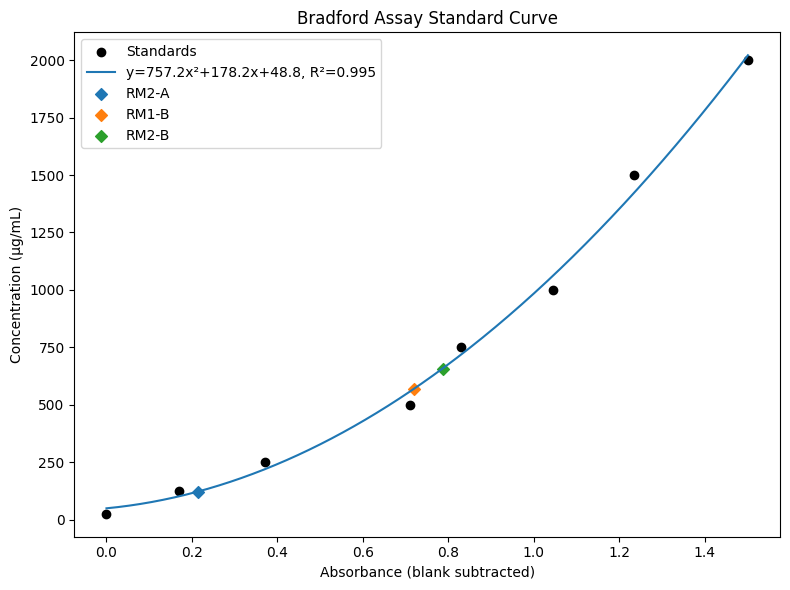

In [ ]:
from bradford_analysis.plotting import BradfordPlotter

BradfordPlotter.plot(analysis, show_legend=True)